In [19]:
import numpy as np
import skimage.transform
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import os
import glob
%pylab inline --no-import-all
matplotlib.rcParams['image.origin'] = 'lower'
matplotlib.rcParams['image.interpolation'] = 'nearest' 
matplotlib.rcParams['image.cmap'] = 'gray'

Populating the interactive namespace from numpy and matplotlib


### Dictionary to map labels to file names

In [20]:
prim_key_map = {'luvoir15m':'LUVOIR15m',
                'luvoir2017novAp01':'Aperture_1', 'luvoir2017novAp01c':'Aperture_1',
                'luvoir2017novAp02':'Aperture_2', 'luvoir2017novAp02c':'Aperture_2',
                'luvoir2017novAp03':'Aperture_3', 'luvoir2017novAp03c':'Aperture_3',
                'luvoir2017novAp04':'Aperture_4', 'luvoir2017novAp04c':'Aperture_4',
                'luvoir2017novAp05':'Aperture_5', 'luvoir2017novAp05c':'Aperture_5',
                'luvoir2017novAp05s':'Aperture_5', 'luvoir2017novAp05b':'Aperture_5',
                'luvoir2017novAp06':'Aperture_6', 'luvoir2017novAp06c':'Aperture_6',
                'luvoir2017novAp07':'Aperture_7', 'luvoir2017novAp07c':'Aperture_7',
                'luvoir2017novAp08':'Aperture_8', 'luvoir2017novAp08c':'Aperture_8',
                'luvoir2017novAp09':'Aperture_9', 'luvoir2017novAp09c':'Aperture_9',
                'luvoir2017novAp10':'Aperture_10', 'luvoir2017novAp10c':'Aperture_10',
                'luvoir2017novAp11':'Aperture_11', 'luvoir2017novAp11c':'Aperture_11',
               }

secobs_key_map = {'Cross':'cross', 'X':'x','s':'straight','b':'bent'}

#diameter of minimum square box enclosing the illuminated aperture
prim_D_box = {'luvoir2017novAp01':2048, 'luvoir2017novAp01c':2048,
              'luvoir2017novAp02':2048, 'luvoir2017novAp02c':2048,
              'luvoir2017novAp03':2048, 'luvoir2017novAp03c':2048,
              'luvoir2017novAp04':1814, 'luvoir2017novAp04c':1814,
              'luvoir2017novAp05':1900, 'luvoir2017novAp05c':1900,
              'luvoir2017novAp05s':1900, 'luvoir2017novAp05b':1900,
              'luvoir2017novAp06':1900, 'luvoir2017novAp06c':1900,
              'luvoir2017novAp07':1814, 'luvoir2017novAp07c':1814,
              'luvoir2017novAp08':2048, 'luvoir2017novAp08c':2048,
              'luvoir2017novAp09':2048, 'luvoir2017novAp09c':2048,
              'luvoir2017novAp10':1840, 'luvoir2017novAp10c':1840,
              'luvoir2017novAp11':1840, 'luvoir2017novAp11c':1840}

## set directory of telescope aperture and list contents

In [21]:
# Neil
#gsfc_telap_dir = os.path.expanduser('~/LUVOIR/LUVOIR Aperture files')

# Kathryn:
jpl_telap_dir = os.path.abspath('/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files')
gsfc_telap_dir = os.path.expanduser('/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files')

#telap_dir = os.path.normpath('/astro/opticslab1/SCDA/Apertures/JPL/offset_masks')
#print telap_dir
#print("Contents:")
#os.listdir(telap_dir)

In [22]:
# Neil
#new_telap_dir = os.path.abspath("/Users/kstlaurent/Documents/SCDA_2/input_files/apertures")

# Kathryn:
new_telap_dir = os.path.expanduser("/Users/kstlaurent/Documents/SCDA_2/input_files/apertures")

if not os.path.exists(new_telap_dir):
    os.mkdir(new_telap_dir)
    print("created {:s} for binned aperture arrays".format(new_telap_dir))
else:
    print("Destination {:s} already exists".format(new_telap_dir))

Destination /Users/kstlaurent/Documents/SCDA_2/input_files/apertures already exists


In [23]:
glob.glob(os.path.normpath(gsfc_telap_dir+'/*.fits'))

['/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/Aperture_1.fits',
 '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/Aperture_10.fits',
 '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/Aperture_10_Struts.fits',
 '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/Aperture_11.fits',
 '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/Aperture_11_Struts.fits',
 '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/Aperture_1_Struts.fits',
 '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/Aperture_2.fits',
 '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/Aperture_2_Struts.fits',
 '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/Aperture_3.fits',
 '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/Aperture_3_Struts.fits',
 '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files/

## Set basic parameters

In [24]:
overwrite = False
#prim_key = "luvoir15m"
prim_key = "luvoir2017novAp05s"
secobs_key = "s"
centobs = True
#Dprim = 4096
if prim_key in prim_D_box:
    Dprim = prim_D_box[prim_key]
    Dsec = Dprim
else:
    Dprim = 4096
    Dsec = Dprim

N = 150/2 # quadrant width after binning
symm = 'full' # set to either 'quart' or 'half'
gap = 2 # minimum segment gap width at N=250 after rounding to binary
strut = 100 # strut thickness parameter; 100 = 10 cm @ 12 m aperture, 25 = 2.5 cm @ 12 m aperture
cut_corner_segs = False

In [25]:
prim_key

'luvoir2017novAp05s'

## Load an aperture and a secondary obstruction, plot the product

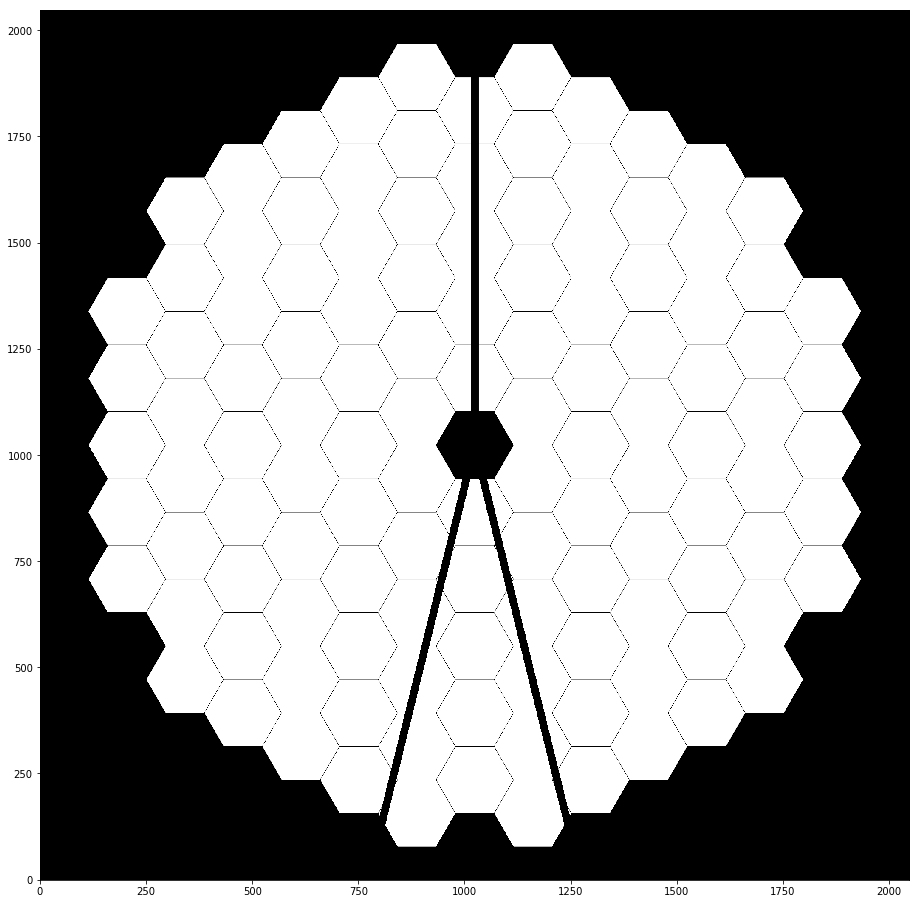

In [26]:
if prim_key == 'luvoir15m':
    prim_fname = os.path.join(gsfc_telap_dir, "{0:s}_{1:04d}pix.fits".format(prim_key_map[prim_key], Dprim))
elif 'luvoir2017nov' in prim_key:
    if secobs_key=='s':
        prim_fname = os.path.join(gsfc_telap_dir, "{0:s}.fits".format(prim_key_map[prim_key]))
        secobs_fname = os.path.join(gsfc_telap_dir, "{0:s}_Struts_straight.fits".format(prim_key_map[prim_key], prim_key[-1]))        
    else:
        prim_fname = os.path.join(gsfc_telap_dir, "{0:s}.fits".format(prim_key_map[prim_key]))
        secobs_fname = os.path.join(gsfc_telap_dir, "{0:s}_Struts_bent.fits".format(prim_key_map[prim_key]))
else:
    prim_fname = os.path.join(jpl_telap_dir, "{0:s}_{1:04d}pix_offset_no_central_obsc.fits".format(
                              prim_key_map[prim_key], D))
    secobs_fname = os.path.join(jpl_telap_dir, "{0:s}_spiders_{1:04d}pix_{2:.1f}cm_offset.fits".format(
                                secobs_key_map[secobs_key], Dsec, float(strut)*0.1))



#prim_fname = os.path.join(gsfc_telap_dir, "{0:s}_{1:04d}pix.fits".format(prim_key_map[prim_key], Dprim))

prim = fits.getdata(prim_fname)
secobs = fits.getdata(secobs_fname)

telap = prim*secobs

    
plt.figure(figsize=(16,16))
plt.imshow(telap)

In [27]:
L = telap.shape[0]
telap_left = telap[:,:L/2] # left half
telap_right = telap[:,L/2:] # right half
telap_top = telap[L/2:,:] # left half
telap_bot = telap[:L/2,:] # right half
leftright_diff = telap_left - telap_right[:,::-1]
topbot_diff = telap_top - telap_bot[::-1,:]
max_abs_leftright_diff = np.max(np.abs(leftright_diff))
max_abs_topbot_diff = np.max(np.abs(topbot_diff))
print('Max absolute left-right difference = {:g}'.format(max_abs_leftright_diff))
print('Max absolute top-bottom difference = {:g}'.format(max_abs_topbot_diff))

Max absolute left-right difference = 1
Max absolute top-bottom difference = 1


## Pad the primary obscuration features

In [28]:
if gap is 0:
    max_shift = 0.
if gap is 1:
    max_shift = Dprim*1.2/1000
elif gap is 2:
    max_shift = Dprim*1.8/1000
elif gap is 3:
    max_shift = Dprim*2.4/1000
shift_range = np.linspace(-max_shift,max_shift,7)
[Xshifts, Yshifts] = np.meshgrid(shift_range, shift_range)
allowed_shifts = np.less_equal(Xshifts**2 + Yshifts**2, max_shift**2)
XYshifts_allowed = zip(Xshifts[allowed_shifts], Yshifts[allowed_shifts])

print("Shift range on each axis: {}".format(shift_range))
print("Shifting telescope pupil array up to +/-{:.2f} pixels in each direction, using {:d} x,y shift combinations, to build up a padded version".format(max_shift, len(XYshifts_allowed)))

Shift range on each axis: [-3.42 -2.28 -1.14  0.    1.14  2.28  3.42]
Shifting telescope pupil array up to +/-3.42 pixels in each direction, using 29 x,y shift combinations, to build up a padded version


In [29]:
padded_telap = np.ones(telap.shape)
for (xshift,yshift) in XYshifts_allowed:
    shift = skimage.transform.SimilarityTransform(translation=(xshift,yshift))
    telap_shifted = skimage.transform.warp(telap, shift, order=1)
    #telap_shifted = np.roll(np.roll(telap, yshift, 0), xshift, 1)
    padded_telap *= telap_shifted

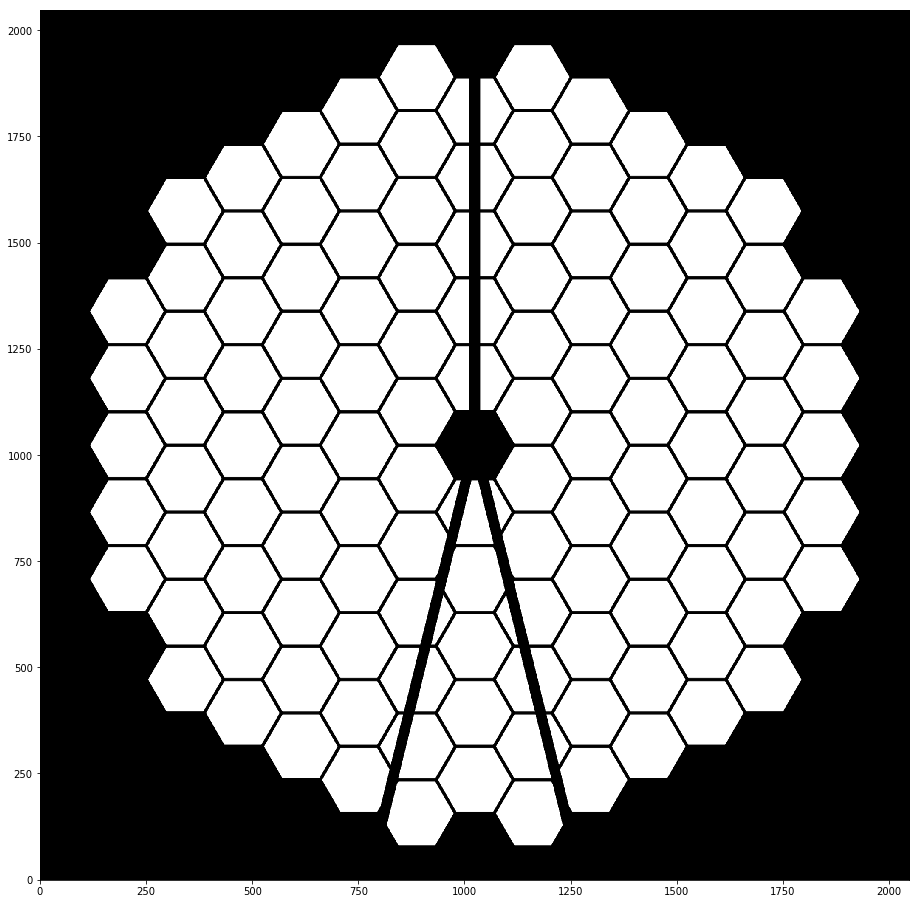

In [30]:
plt.figure(figsize=(16,16))
plt.imshow(padded_telap)

In [31]:
if gap is 0:
    max_shift = 0.
if gap is 1:
    max_shift = Dsec*0.2/1000
elif gap is 2:
    max_shift = Dsec*1.1/1000
elif gap is 3:
    max_shift = Dsec*1.8/1000
shift_range = np.linspace(-max_shift,max_shift,7)
[Xshifts, Yshifts] = np.meshgrid(shift_range, shift_range)
allowed_shifts = np.less_equal(Xshifts**2 + Yshifts**2, max_shift**2)
XYshifts_allowed = zip(Xshifts[allowed_shifts], Yshifts[allowed_shifts])

print("Shift range on each axis: {}".format(shift_range))
print("Shifting telescope pupil array up to +/-{:.2f} pixels in each direction, using {:d} x,y shift combinations, to build up a padded version".format(max_shift, len(XYshifts_allowed)))

Shift range on each axis: [-2.09       -1.39333333 -0.69666667  0.          0.69666667  1.39333333
  2.09      ]
Shifting telescope pupil array up to +/-2.09 pixels in each direction, using 29 x,y shift combinations, to build up a padded version


In [32]:
padded_secobs = np.ones(secobs.shape)
for (xshift,yshift) in XYshifts_allowed:
    shift = skimage.transform.SimilarityTransform(translation=(xshift,yshift))
    secobs_shifted = skimage.transform.warp(secobs, shift, order=1)
    padded_secobs *= secobs_shifted

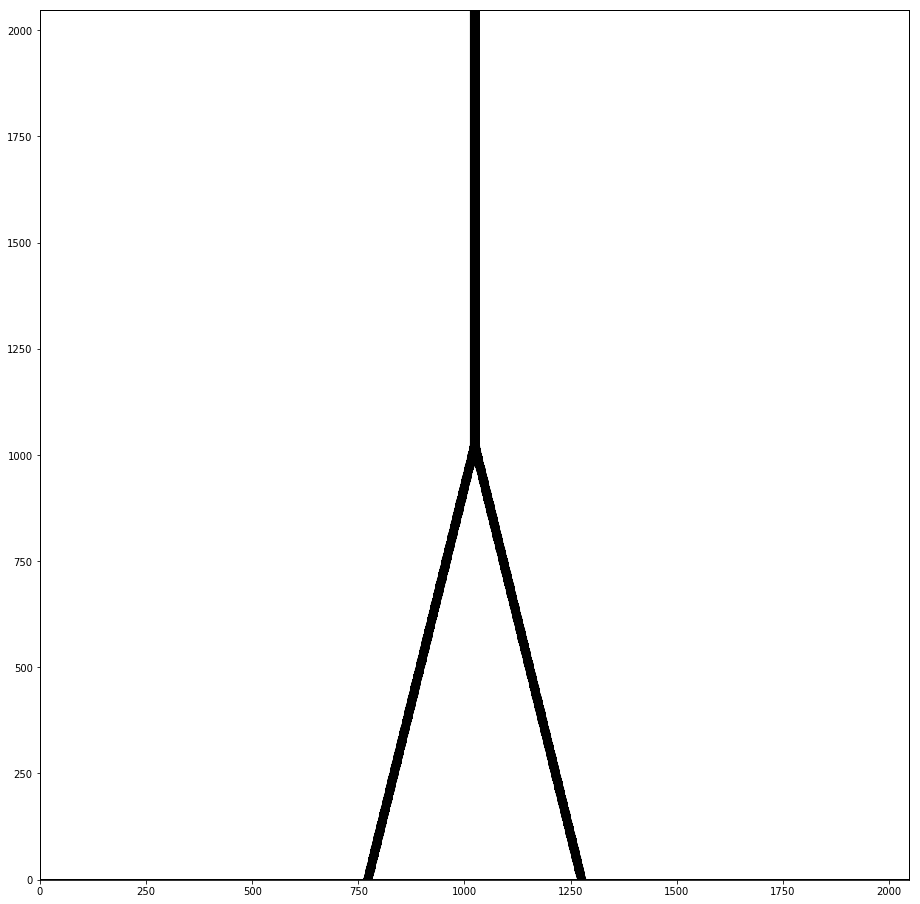

In [33]:
plt.figure(figsize=(16,16))
plt.imshow(padded_secobs)

## Bin to abritrary integer size, crop

In [34]:
#N_orig = D/2
#telap_bin = skimage.transform.resize(padded_telap,(2*N,2*N),order=1)
#L_bin = telap_bin.shape[0]

In [35]:
Dprim/2 % 128

54

In [36]:
N_orig = Dprim/2

if N_orig % N == 0:
    scalefac = N_orig // N
    print("Binning the original aperture array {0:d}x".format(scalefac))
    prim_bin = np.reshape(padded_telap,(telap.shape[0]/scalefac, scalefac, 
                                        telap.shape[1]/scalefac, scalefac)).mean(1).mean(2)
    secobs_bin = skimage.transform.rescale(secobs, 1./scalefac, order=1)
else:
    scalefac = float(N_orig) / N
    print("Binning the original aperture array {0:.3f}x".format(scalefac))
    prim_bin = skimage.transform.rescale(padded_telap, 1./scalefac, order=1)  
    secobs_bin = skimage.transform.rescale(padded_secobs, 1./scalefac, order=1)

L_bin = prim_bin.shape[0]

Binning the original aperture array 12.667x


/Users/kstlaurent/anaconda2/lib/python2.7/site-packages/skimage/transform/_warps.py:84: UserWarning: The default mode, 'constant', will be changed to 'reflect' in skimage 0.15.
  warn("The default mode, 'constant', will be changed to 'reflect' in "


In [37]:
#N_orig = Dsec/2
#scalefac = int(N_orig/N)
#print("Binning the secondary obscuration array {0:d}x".format(scalefac))

#if strut == 100:
#    secobs_bin = skimage.transform.resize(secobs,(2*N,2*N),order=1)
#else: # only pad the thin strut
#    secobs_bin = skimage.transform.resize(padded_secobs,(2*N,2*N),order=1)

In [38]:
telap_bin = prim_bin*secobs_bin

In [39]:
telap_bin.shape

(162, 162)

In [40]:
if symm is 'half':
    telap_bin_crop = telap_bin[L_bin//2-N:L_bin//2+N, L_bin//2:L_bin//2+N]
    print telap_bin_crop.shape
elif symm is 'full':
    telap_bin_crop = telap_bin[L_bin//2-N:L_bin//2+N,L_bin//2-N:L_bin//2+N]
    print telap_bin_crop.shape 
else:
    telap_bin_crop = telap_bin[L_bin//2:L_bin//2+N, L_bin//2:L_bin//2+N]
    print telap_bin_crop.shape
    # Check max value of outer row and outer column
    #print np.max(telap_binquad[-1,:])
    #print np.max(telap_binquad[:,-1])
    
telap_bin_full = telap_bin[L_bin//2-N:L_bin//2+N, L_bin//2-N:L_bin//2+N]

(150, 150)


(-0.5, 149.5, -0.5, 149.5)

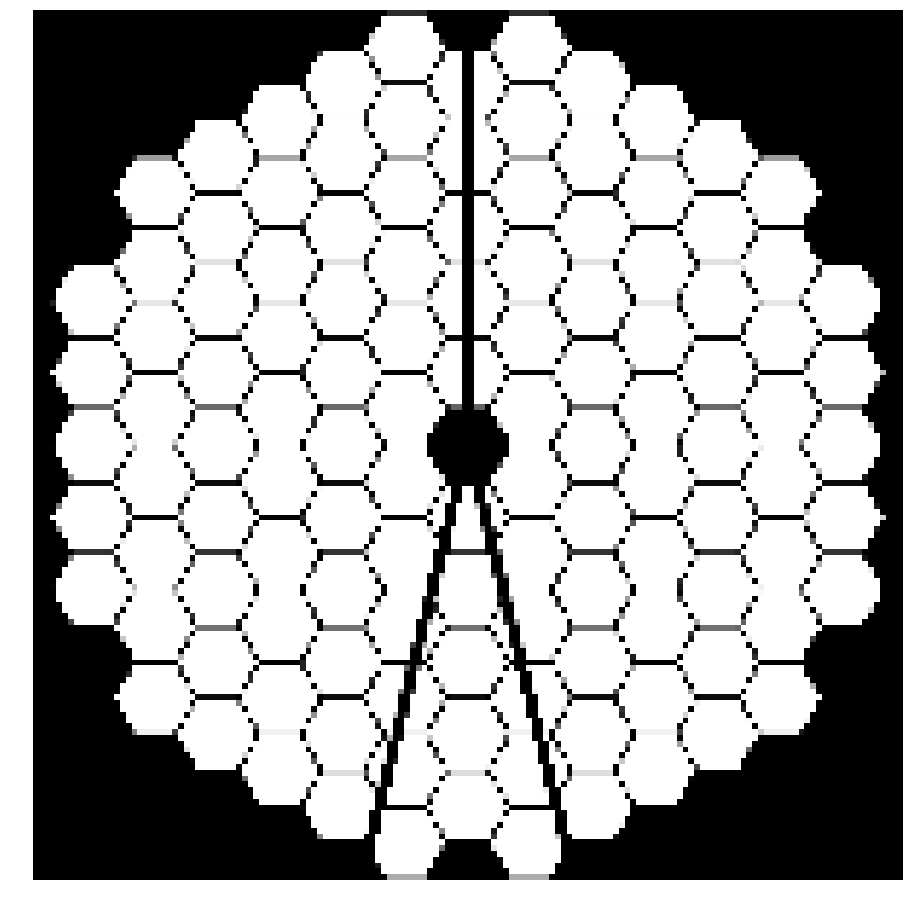

In [41]:
if symm is 'half':
    plt.figure(figsize=(16,32))
    plt.imshow(telap_bin_crop)
else:
    plt.figure(figsize=(16,16))
    plt.imshow(telap_bin_crop)
    #plt.imshow(np.floor(telap_bin_crop))
    #plt.imshow(np.round(telap_bin_crop))
plt.axis('off')

### Form new FITS filename and write

In [42]:
if symm is 'half':
    telap_bin_fits_fname_tail = "TelAp_half_{0:s}{1:s}{2:03d}cobs1gap{3:1d}_N{4:04d}.fits".format(
                                prim_key, secobs_key, strut, gap, N)
    telap_bin_fits_fname = os.path.join(new_telap_dir, telap_bin_fits_fname_tail)
elif symm is 'full':
    telap_bin_fits_fname_tail = "TelAp_full_{0:s}{1:s}{2:03d}cobs1gap{3:1d}_N{4:04d}.fits".format(
                                prim_key, secobs_key, strut, gap, N*2)
    telap_bin_fits_fname = os.path.join(new_telap_dir, telap_bin_fits_fname_tail)
else:
    telap_bin_fits_fname_tail = "TelAp_quart_{0:s}{1:s}{2:03d}cobs1gap{3:1d}_N{4:04d}.fits".format(
                                prim_key, secobs_key, strut, gap, N)
    telap_bin_fits_fname = os.path.join(new_telap_dir, telap_bin_fits_fname_tail)
    
print(telap_bin_fits_fname)

/Users/kstlaurent/Documents/SCDA_2/input_files/apertures/TelAp_full_luvoir2017novAp05ss100cobs1gap2_N0150.fits


In [43]:
#telap_binquad_hdu = fits.PrimaryHDU(telap_binquad)
#telap_binquad_hdu.writeto(telap_binquad_fits_fname, clobber=True)

In [44]:
if not os.path.exists(telap_bin_fits_fname) or overwrite==True:
    telap_full_hdu = fits.PrimaryHDU(np.round(telap_bin_full).astype(int))
    telap_full_hdu.writeto(telap_bin_fits_fname, overwrite=True)
    print("Wrote full, rounded telescope pupil to {:s}".format(telap_bin_fits_fname))

Wrote full, rounded telescope pupil to /Users/kstlaurent/Documents/SCDA_2/input_files/apertures/TelAp_full_luvoir2017novAp05ss100cobs1gap2_N0150.fits


In [45]:
#if os.path.exists(telap_bin_dat_fname): os.remove(telap_bin_dat_fname)

In [46]:
print new_telap_dir
os.listdir(new_telap_dir)

/Users/kstlaurent/Documents/SCDA_2/input_files/apertures


['.DS_Store',
 'HiCAT-Aper_F-N0290_Hex3-Ctr0972-Obs0195-SpX0017-Gap0004.fits',
 'HiCAT-Aper_F-N0486_Hex3-Ctr0972-Obs0195-SpX0017-Gap0004.fits',
 'pupil=sbr_nPup=50.fits',
 'TelAp_full_luvoir2017novAp05ss100cobs1gap2_N0150.fits',
 'TelAp_full_luvoir2017novAp05ss100cobs1gap2_N0250.fits',
 'TelAp_full_luvoir2017novAp05ss100cobs1gap2_N0290.fits',
 'TelAp_full_luvoir2017novAp05ss100cobs1gap2_N0450.fits',
 'TelAp_full_luvoir2017novAp05ss100cobs1gap2_N0500.fits']

## Compute the loss in available energy due to padding of obscuration features

In [47]:
dxb = 1./(2*N)
dx = 1./Dprim
padding_energy_loss_factor = np.sum(np.round(telap_bin_full)*dxb*dxb) / np.sum(np.power(telap,2)*dx*dx)
print("Percentage of available energy from telescope after feature padding = {:.2f}%".format(padding_energy_loss_factor*100))

Percentage of available energy from telescope after feature padding = 91.42%


In [48]:
print("Collecting area of padded, binned aperture: {:.4f}".format(
         2*np.sum(np.power(telap_bin_crop,2))*dxb*dxb))

In [49]:
print("Collecting area of optimization aperture: {:.4f}".format(
         2*np.sum(np.round(telap_bin_crop))*dxb*dxb))

In [50]:
print("Collecting area of original aperture array: {:.4f}".format(
            np.sum(np.power(telap,2))*dx*dx))